In [536]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/Sample_ Superstore (1).csv")






In [537]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


In [538]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Consumer,United States,Miami,Florida,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Consumer,United States,Costa Mesa,California,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Consumer,United States,Costa Mesa,California,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Consumer,United States,Costa Mesa,California,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,05-04-2017,05-09-2017,Second Class,CC-12220,Consumer,United States,Westminster,California,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [539]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [540]:
df["Region"].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [541]:
df["Segment"].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [542]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

# Data Profiling Observations

- Dataset contains 9,994 rows and 19 columns.
- No missing values were found.
- Order Date and Ship Date are stored as object and need conversion to datetime.
- Sales, Profit, Discount, and Quantity are numerical.
- Dataset contains 3 product categories.
- Dataset contains 4 regions.
- Customer segment is divided into Consumer, Corporate, and Home Office.

In [543]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   str    
 2   Order Date    9994 non-null   str    
 3   Ship Date     9994 non-null   str    
 4   Ship Mode     9994 non-null   str    
 5   Customer ID   9994 non-null   str    
 6   Segment       9994 non-null   str    
 7   Country       9994 non-null   str    
 8   City          9994 non-null   str    
 9   State         9994 non-null   str    
 10  Region        9994 non-null   str    
 11  Product ID    9994 non-null   str    
 12  Category      9994 non-null   str    
 13  Sub-Category  9994 non-null   str    
 14  Product Name  9994 non-null   str    
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit        9994 non-null   float64
d

In [544]:
clean_df = df.copy()


In [545]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [546]:
df.shape


(9994, 19)

In [547]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [548]:
df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [549]:
df.duplicated().sum()

np.int64(0)

In [550]:
df.nunique()

Row ID          9994
Order ID        5009
Order Date      1237
Ship Date       1334
Ship Mode          4
Customer ID      793
Segment            3
Country            1
City             531
State             49
Region             4
Product ID      1862
Category           3
Sub-Category      17
Product Name    1850
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

In [551]:
clean_df.isnull().sum()

Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [552]:
clean_df.isnull().mean()*100

Row ID          0.0
Order ID        0.0
Order Date      0.0
Ship Date       0.0
Ship Mode       0.0
Customer ID     0.0
Segment         0.0
Country         0.0
City            0.0
State           0.0
Region          0.0
Product ID      0.0
Category        0.0
Sub-Category    0.0
Product Name    0.0
Sales           0.0
Quantity        0.0
Discount        0.0
Profit          0.0
dtype: float64

In [553]:
clean_df.duplicated().sum()

np.int64(0)

In [554]:
clean_df = clean_df.drop_duplicates()

In [555]:
clean_df.duplicated().sum()

np.int64(0)

In [556]:
clean_df["Order Date"].head(10)

0    11-08-2016
1    11-08-2016
2    06-12-2016
3    10-11-2015
4    10-11-2015
5    06-09-2014
6    06-09-2014
7    06-09-2014
8    06-09-2014
9    06-09-2014
Name: Order Date, dtype: str

In [557]:
clean_df[clean_df["Order Date"].str.contains("/", na=False)]["Order Date"].head(20)

12     4/15/2017
14    11/22/2015
15    11/22/2015
17     5/13/2014
18     8/27/2014
19     8/27/2014
20     8/27/2014
23     7/16/2017
24     9/25/2015
25     1/16/2016
26     1/16/2016
27     9/17/2015
28     9/17/2015
29     9/17/2015
30     9/17/2015
31     9/17/2015
32     9/17/2015
33     9/17/2015
34    10/19/2017
37    12/27/2015
Name: Order Date, dtype: str

In [558]:
clean_df["Order Date"] = pd.to_datetime(
    clean_df["Order Date"],
    format="mixed"
)

clean_df["Ship Date"] = pd.to_datetime(
    clean_df["Ship Date"],
    format="mixed"
)

In [559]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   str           
 2   Order Date    9994 non-null   datetime64[us]
 3   Ship Date     9994 non-null   datetime64[us]
 4   Ship Mode     9994 non-null   str           
 5   Customer ID   9994 non-null   str           
 6   Segment       9994 non-null   str           
 7   Country       9994 non-null   str           
 8   City          9994 non-null   str           
 9   State         9994 non-null   str           
 10  Region        9994 non-null   str           
 11  Product ID    9994 non-null   str           
 12  Category      9994 non-null   str           
 13  Sub-Category  9994 non-null   str           
 14  Product Name  9994 non-null   str           
 15  Sales         9994 non-null   float64       
 16 

In [560]:
clean_df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [561]:
clean_df[clean_df["Sales"] < 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [562]:
clean_df[clean_df["Quantity"] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [563]:
clean_df["Discount"].describe()

count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64

In [564]:
clean_df[
    (clean_df["Discount"] < 0) |
    (clean_df["Discount"] > 1)
]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [565]:
clean_df["Profit"].describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

In [566]:
import matplotlib.pyplot as plt

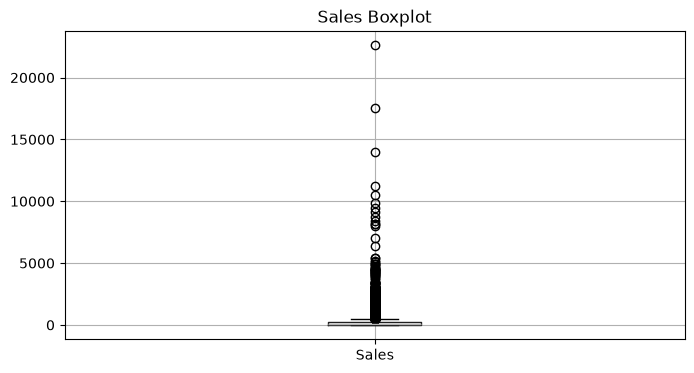

In [567]:
plt.figure(figsize=(8,4))
clean_df.boxplot(column="Sales")
plt.title("Sales Boxplot")
plt.show()

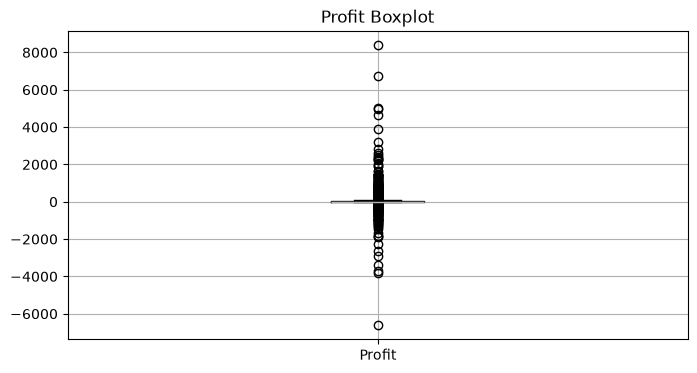

In [568]:
plt.figure(figsize=(8,4))
clean_df.boxplot(column="Profit")
plt.title("Profit Boxplot")
plt.show()

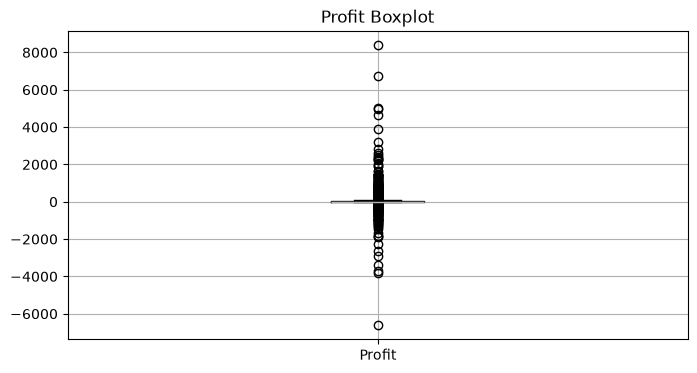

In [569]:
plt.figure(figsize=(8,4))
clean_df.boxplot(column="Profit")
plt.title("Profit Boxplot")
plt.show()

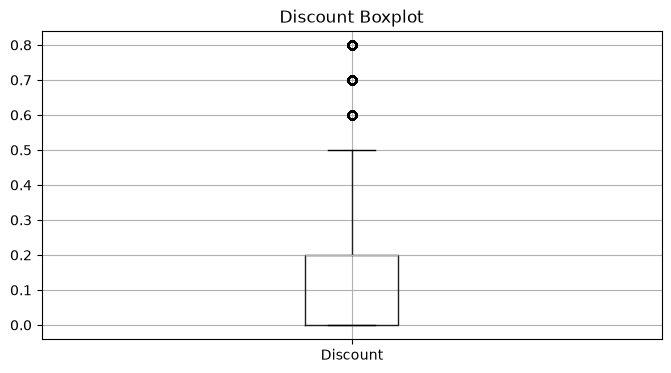

In [570]:
plt.figure(figsize=(8,4))
clean_df.boxplot(column="Discount")
plt.title("Discount Boxplot")
plt.show()

In [571]:
clean_df["Category"].unique()

<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

In [572]:
clean_df["Region"].unique()

<ArrowStringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

In [573]:
clean_df["Segment"].unique()

<ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [574]:
clean_df["Ship Mode"].unique()

<ArrowStringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

In [575]:
clean_df.to_csv(
    "../data/processed/cleaned_superstore.csv",
    index=False
)

In [576]:
clean_df["Order Year"] = clean_df["Order Date"].dt.year

In [577]:
clean_df[["Order Date", "Order Year"]].head()

,Order Date,Order Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [578]:
clean_df["Order Month"] = clean_df["Order Date"].dt.month

In [579]:
clean_df[["Order Date", "Order Month"]].head()

,Order Date,Order Month
0,2016-11-08,11
1,2016-11-08,11
2,2016-06-12,6
3,2015-10-11,10
4,2015-10-11,10


In [580]:
clean_df["Month Name"] = clean_df["Order Date"].dt.month_name()

In [581]:
clean_df["Quarter"] = clean_df["Order Date"].dt.quarter

In [582]:
clean_df["Day Name"] = clean_df["Order Date"].dt.day_name()

In [583]:
clean_df["Is Weekend"] = clean_df["Day Name"].isin(
    ["Saturday", "Sunday"]
)

In [584]:
clean_df["Shipping Days"] = (
    clean_df["Ship Date"] -
    clean_df["Order Date"]
).dt.days

In [585]:
clean_df["Profit Margin"] = (
    clean_df["Profit"] /
    clean_df["Sales"]
)

In [586]:
clean_df["Average Selling Price"] = (
    clean_df["Sales"] /
    clean_df["Quantity"]
)

In [587]:
clean_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Profit,Order Year,Order Month,Month Name,Quarter,Day Name,Is Weekend,Shipping Days,Profit Margin,Average Selling Price
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,41.9136,2016,11,November,4,Tuesday,False,3,0.1600,130.9800
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,219.5820,2016,11,November,4,Tuesday,False,3,0.3000,243.9800
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,...,6.8714,2016,6,June,2,Sunday,True,4,0.4700,7.3100
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,-383.0310,2015,10,October,4,Sunday,True,7,-0.4000,191.5155
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,2.5164,2015,10,October,4,Sunday,True,7,0.1125,11.1840


In [588]:
clean_df.to_csv(
    "../data/processed/cleaned_superstore.csv",
    index=False
)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
df = pd.read_csv("../data/processed/cleaned_superstore.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 28


In [6]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed"
)

In [7]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Profit,Order Year,Order Month,Month Name,Quarter,Day Name,Is Weekend,Shipping Days,Profit Margin,Average Selling Price
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,41.9136,2016,11,November,4,Tuesday,False,3,0.1600,130.9800
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,219.5820,2016,11,November,4,Tuesday,False,3,0.3000,243.9800
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,...,6.8714,2016,6,June,2,Sunday,True,4,0.4700,7.3100
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,-383.0310,2015,10,October,4,Sunday,True,7,-0.4000,191.5155
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,2.5164,2015,10,October,4,Sunday,True,7,0.1125,11.1840


In [9]:
df.shape

(9994, 28)

In [10]:

df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit',
 'Order Year',
 'Order Month',
 'Month Name',
 'Quarter',
 'Day Name',
 'Is Weekend',
 'Shipping Days',
 'Profit Margin',
 'Average Selling Price']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Row ID                 9994 non-null   int64         
 1   Order ID               9994 non-null   str           
 2   Order Date             9994 non-null   datetime64[us]
 3   Ship Date              9994 non-null   datetime64[us]
 4   Ship Mode              9994 non-null   str           
 5   Customer ID            9994 non-null   str           
 6   Segment                9994 non-null   str           
 7   Country                9994 non-null   str           
 8   City                   9994 non-null   str           
 9   State                  9994 non-null   str           
 10  Region                 9994 non-null   str           
 11  Product ID             9994 non-null   str           
 12  Category               9994 non-null   str           
 13  Sub-Category  

In [12]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Order Year,Order Month,Quarter,Shipping Days,Profit Margin,Average Selling Price
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,2.882329,3.958175,0.120314,60.919569
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,1.000000,0.000000,-2.750000,0.336000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,2.000000,3.000000,0.075000,5.470000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,3.000000,4.000000,0.270000,16.270000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,4.000000,5.000000,0.362500,63.940000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,4.000000,7.000000,0.500000,3773.080000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,1.058086,1.747567,0.466754,142.927440


In [13]:
df.isnull().sum()

Row ID                   0
Order ID                 0
Order Date               0
Ship Date                0
Ship Mode                0
Customer ID              0
Segment                  0
Country                  0
City                     0
State                    0
Region                   0
Product ID               0
Category                 0
Sub-Category             0
Product Name             0
Sales                    0
Quantity                 0
Discount                 0
Profit                   0
Order Year               0
Order Month              0
Month Name               0
Quarter                  0
Day Name                 0
Is Weekend               0
Shipping Days            0
Profit Margin            0
Average Selling Price    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

Row ID                   9994
Order ID                 5009
Order Date               1237
Ship Date                1334
Ship Mode                   4
Customer ID               793
Segment                     3
Country                     1
City                      531
State                      49
Region                      4
Product ID               1862
Category                    3
Sub-Category               17
Product Name             1850
Sales                    5825
Quantity                   14
Discount                   12
Profit                   7287
Order Year                  4
Order Month                12
Month Name                 12
Quarter                     4
Day Name                    7
Is Weekend                  2
Shipping Days               8
Profit Margin             437
Average Selling Price    2938
dtype: int64

In [16]:
df[
    ["Sales", "Quantity", "Discount", "Profit",
     "Shipping Days", "Profit Margin", "Average Selling Price"]
].describe()

,Sales,Quantity,Discount,Profit,Shipping Days,Profit Margin,Average Selling Price
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,3.958175,0.120314,60.919569
std,623.245101,2.225110,0.206452,234.260108,1.747567,0.466754,142.927440
min,0.444000,1.000000,0.000000,-6599.978000,0.000000,-2.750000,0.336000
25%,17.280000,2.000000,0.000000,1.728750,3.000000,0.075000,5.470000
50%,54.490000,3.000000,0.200000,8.666500,4.000000,0.270000,16.270000
75%,209.940000,5.000000,0.200000,29.364000,5.000000,0.362500,63.940000
max,22638.480000,14.000000,0.800000,8399.976000,7.000000,0.500000,3773.080000


In [21]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_quantity = df["Quantity"].sum()

average_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Quantity:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))
print("Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Quantity: 37873
Average Order Value: 458.61
Profit Margin: 12.47 %


In [22]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

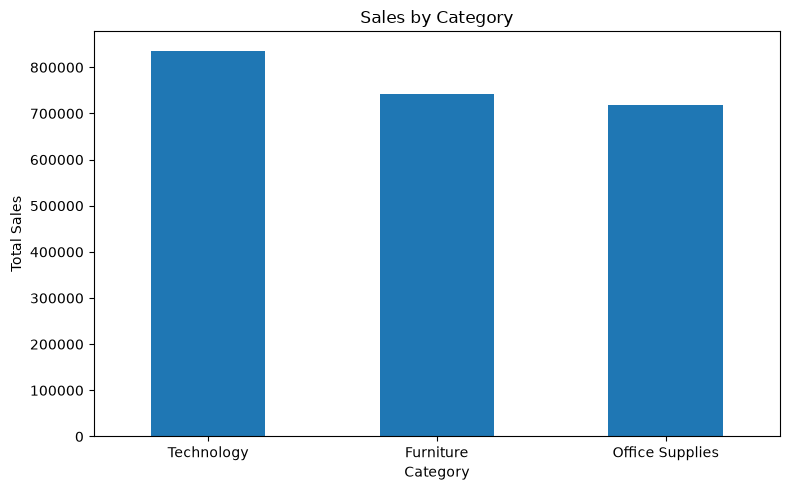

In [23]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

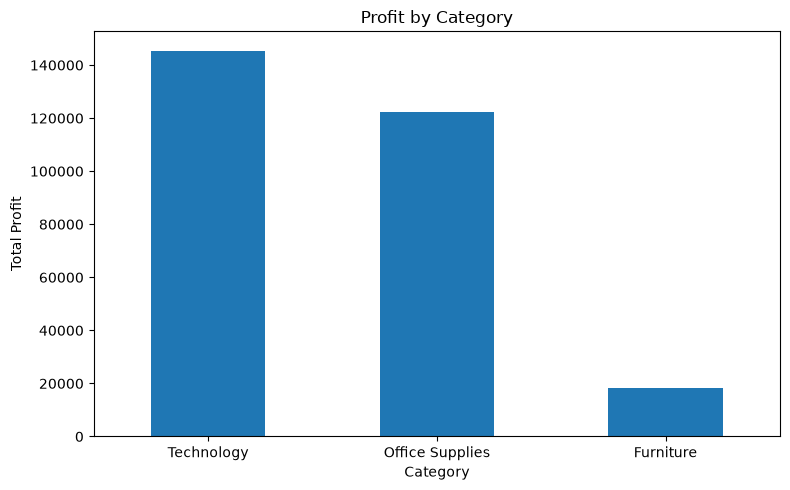

In [25]:
plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

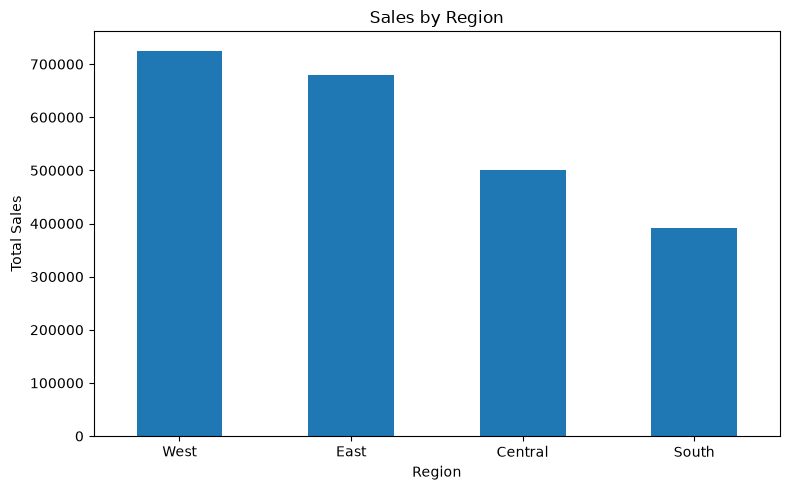

In [27]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [28]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

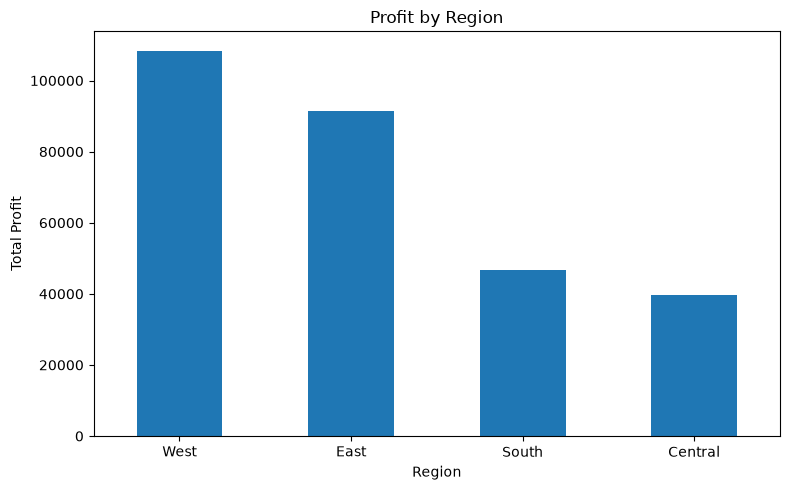

In [29]:
plt.figure(figsize=(8, 5))

region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
    .sum()
)

In [31]:
monthly_sales.head()

Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64

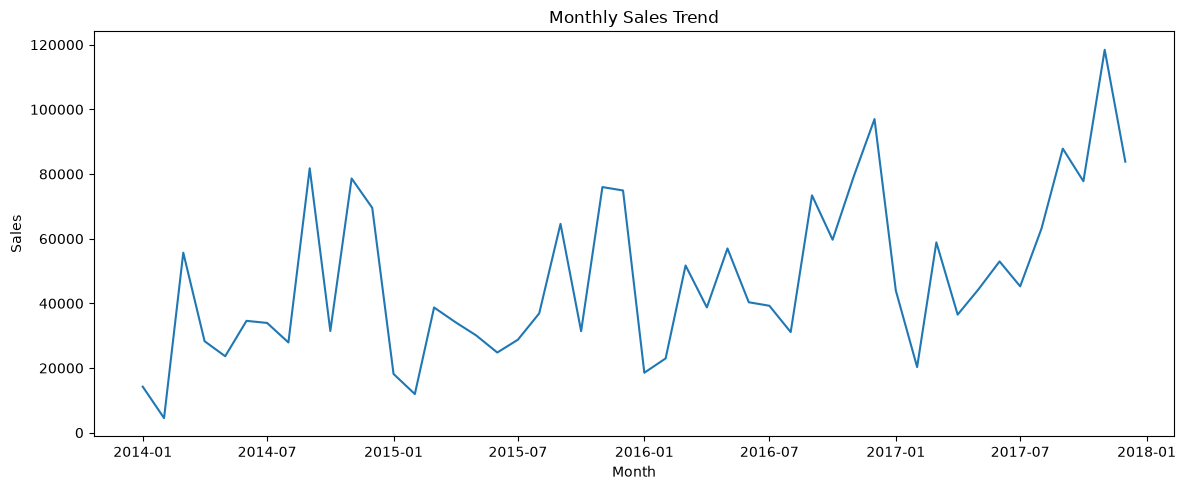

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [33]:
monthly_profit = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Profit"]
    .sum()
)

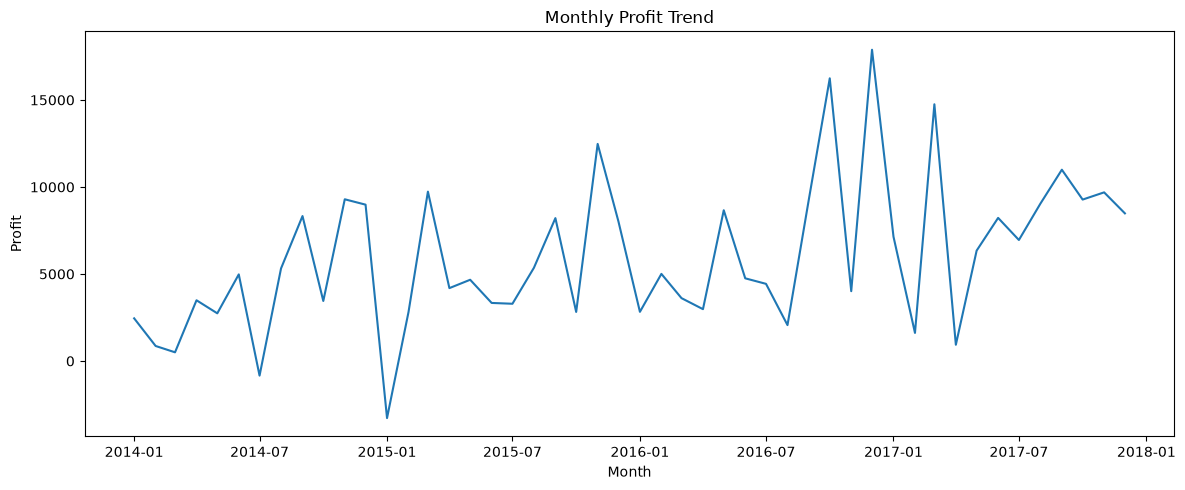

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_profit.index, monthly_profit.values)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

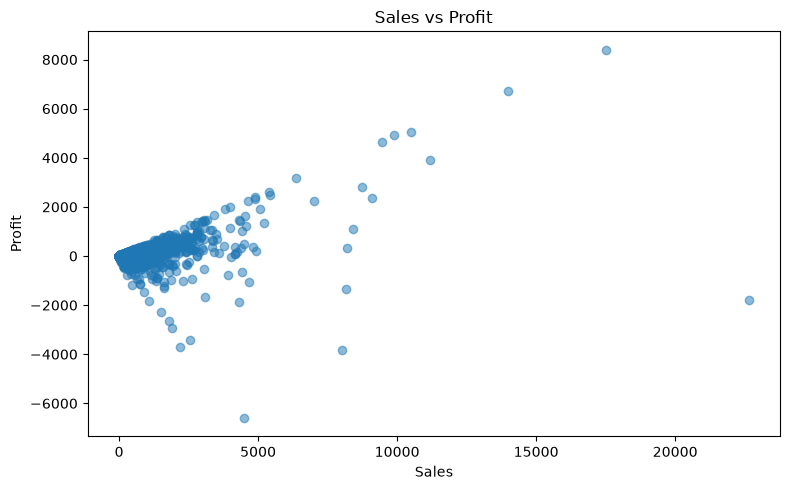

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.5
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

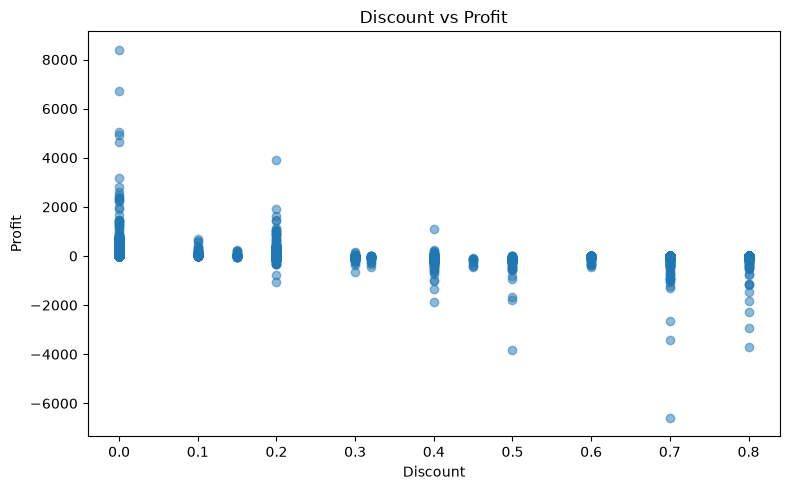

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

               Sales       Profit
Region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489


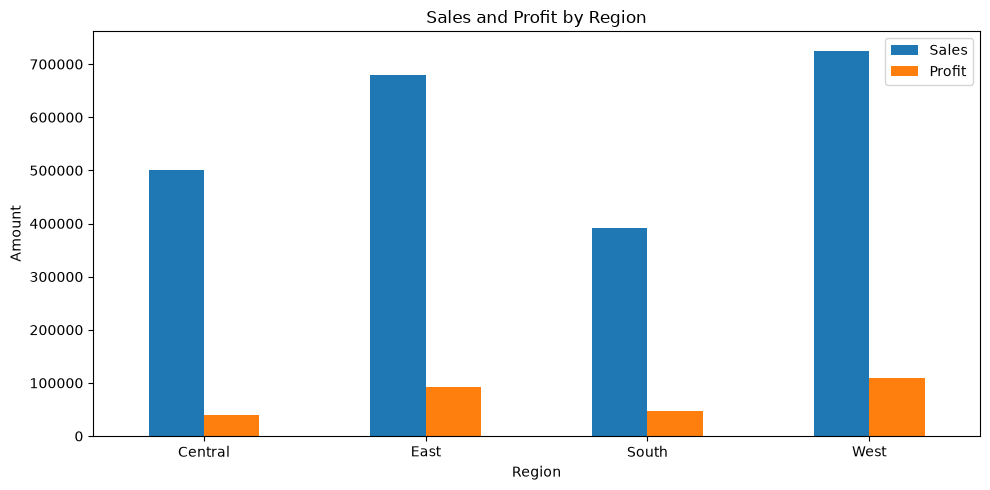

In [37]:
# Regional Sales & Profit
region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum()

print(region_analysis)

region_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

                Sales     Profit
Order Date                      
2014-01-01  14236.895  2450.1907
2014-02-01   4519.892   862.3084
2014-03-01  55691.009   498.7299
2014-04-01  28295.345  3488.8352
2014-05-01  23648.287  2738.7096


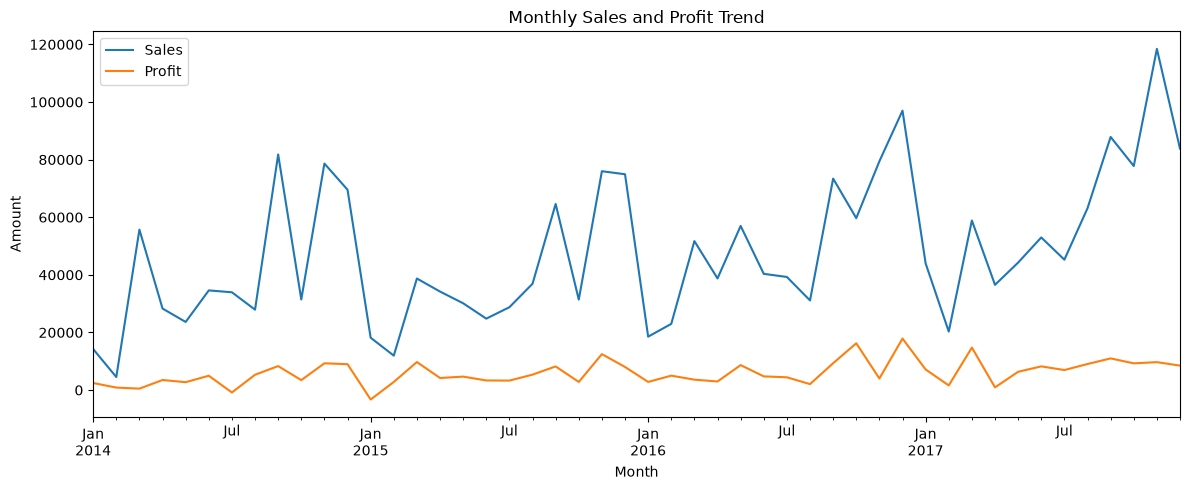

In [38]:
# Monthly Sales & Profit
monthly = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))[
        ["Sales", "Profit"]
    ]
    .sum()
)

print(monthly.head())

monthly.plot(
    figsize=(12, 5)
)

plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

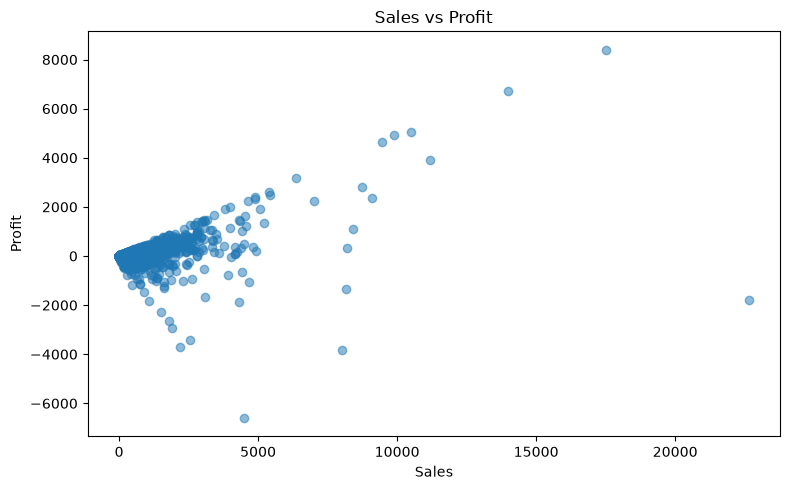

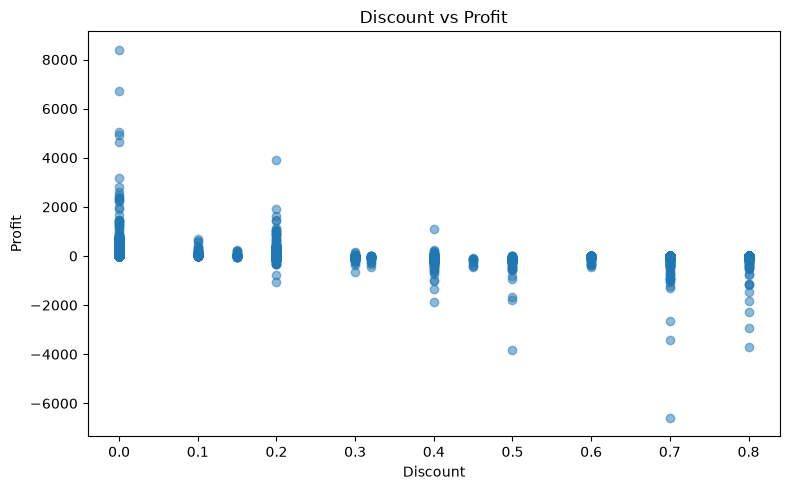

In [39]:
# Sales vs Profit
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.5
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


# Discount vs Profit
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

                          Sales  Quantity  Discount    Profit  Shipping Days  \
Sales                  1.000000  0.200795 -0.028190  0.479064      -0.007354   
Quantity               0.200795  1.000000  0.008623  0.066253       0.018298   
Discount              -0.028190  0.008623  1.000000 -0.219487       0.000408   
Profit                 0.479064  0.066253 -0.219487  1.000000      -0.004649   
Shipping Days         -0.007354  0.018298  0.000408 -0.004649       1.000000   
Profit Margin          0.003444 -0.005280 -0.864452  0.223732      -0.011815   
Average Selling Price  0.889376 -0.003148 -0.032803  0.468312      -0.013390   

                       Profit Margin  Average Selling Price  
Sales                       0.003444               0.889376  
Quantity                   -0.005280              -0.003148  
Discount                   -0.864452              -0.032803  
Profit                      0.223732               0.468312  
Shipping Days              -0.011815             

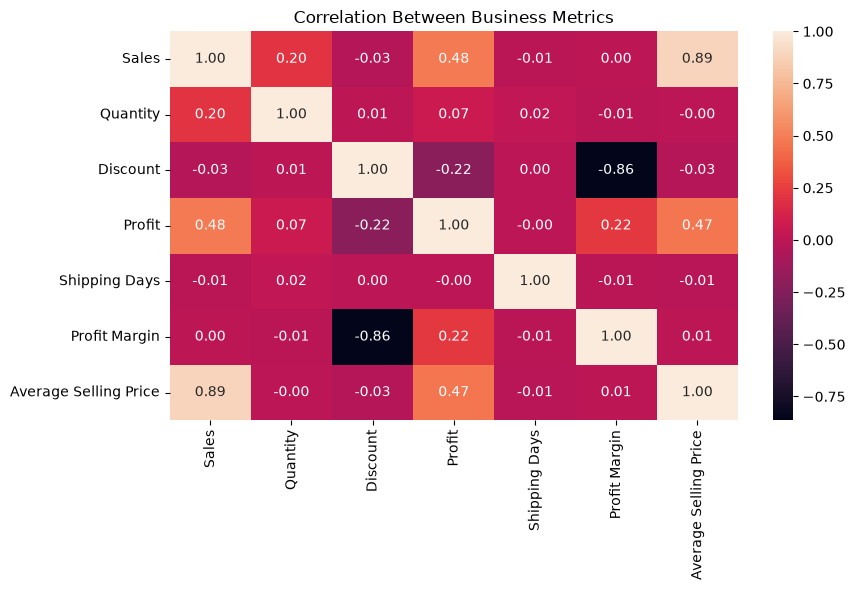

In [40]:
numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Days",
    "Profit Margin",
    "Average Selling Price"
]

correlation = df[numeric_cols].corr()

print(correlation)

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Business Metrics")
plt.tight_layout()
plt.show()

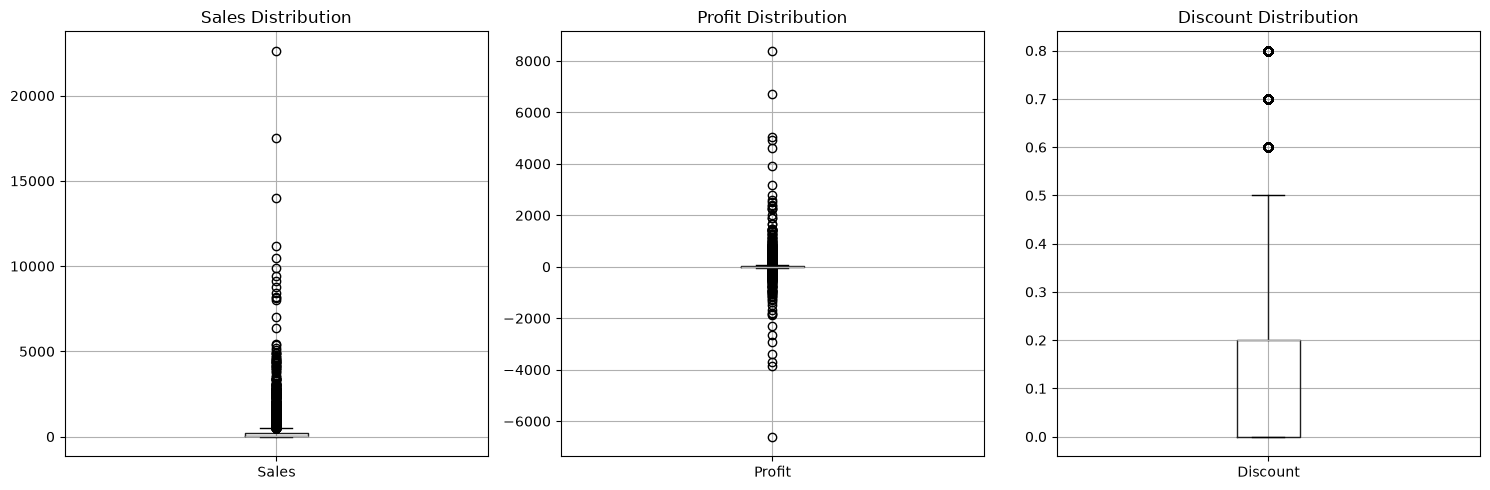

In [41]:
# Boxplots for important numerical variables

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(column="Sales", ax=axes[0])
axes[0].set_title("Sales Distribution")

df.boxplot(column="Profit", ax=axes[1])
axes[1].set_title("Profit Distribution")

df.boxplot(column="Discount", ax=axes[2])
axes[2].set_title("Discount Distribution")

plt.tight_layout()
plt.show()

In [42]:
print("===== BUSINESS INSIGHTS =====")

best_region = df.groupby("Region")["Sales"].sum().idxmax()
best_category = df.groupby("Category")["Sales"].sum().idxmax()
most_profitable_category = df.groupby("Category")["Profit"].sum().idxmax()

print("Highest Sales Region:", best_region)
print("Highest Sales Category:", best_category)
print("Most Profitable Category:", most_profitable_category)

print(
    "Average Discount:",
    round(df["Discount"].mean() * 100, 2),
    "%"
)

print(
    "Overall Profit Margin:",
    round(
        df["Profit"].sum() / df["Sales"].sum() * 100,
        2
    ),
    "%"
)

===== BUSINESS INSIGHTS =====
Highest Sales Region: West
Highest Sales Category: Technology
Most Profitable Category: Technology
Average Discount: 15.62 %
Overall Profit Margin: 12.47 %
